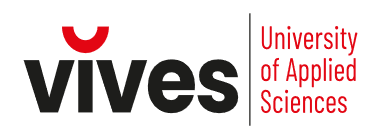<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **POLYNOMIAL REGRESSION: EXERCISES**

In this notebook, we first cover exercises on polynomials, then we perform exercises on fitting data using polynomials, and finally, there are exercises on selecting the best polynomial that neither underfits nor overfits based on the model complexity graph or by applying regularization. This gives us the following sections in the notebook:

1. polynomials
2. polynomial regression
3. underfitting and overfitting

## Polynomials

The following exercises are about calculating and plotting polynomials.

### Exercise 1

Plot the following [Laguerre polynomial](https://en.wikipedia.org/wiki/Laguerre_polynomials):

> $L_6(x) = \frac{1}{720}(x^6-36x^5+450x^4-2400x^3+5400x^2-4320x+720)$

Let $x$ vary between -1 and 16.

Add a grid to your plot. Label your axes.

#### Solution

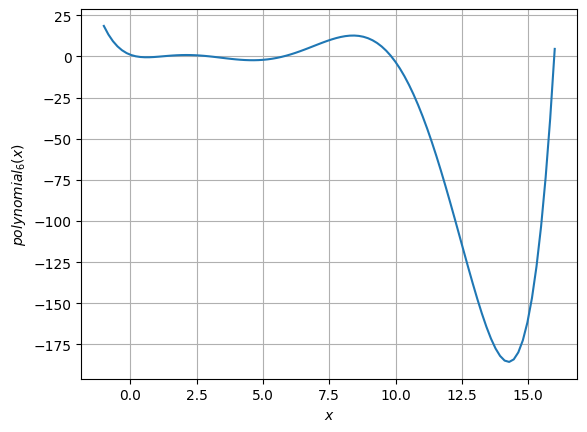

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

coef = np.array([1, -36, 450, -2400, 5400, -4320, 720]) / 720
x = np.linspace(-1, 16, 100);
polynomial_6 = np.polyval(coef, x)

plt.plot(x, polynomial_6);
plt.grid();
plt.xlabel('$x$');  # use $...$ for LaTeX
plt.ylabel('$polynomial_6(x)$');  # use $...$ for LaTeX

### Exercise 2

Set the [trajectory](https://en.wikipedia.org/wiki/Projectile_motion) out for a projectile that is fired horizontally with a speed $v$ of 500 m/s.

The distance $x$ in meters is calculated as follows:

> $x = v.t$

The height $y$ in meters is equal to:

> $y = -\frac{1}{2}.g.t^2$

Here, $t$ is the time in seconds. The constant $g$ is the acceleration due to gravity, which you can take to be 9.81 m/s².

When you combine the two equations, you get the following polynomial:

> $y(x) = -\frac{g.x^2}{2.v^2}$

Plot the track over the interval $x = [0, 1000]$. Add labels to the axes and also add a grid.

#### Solution

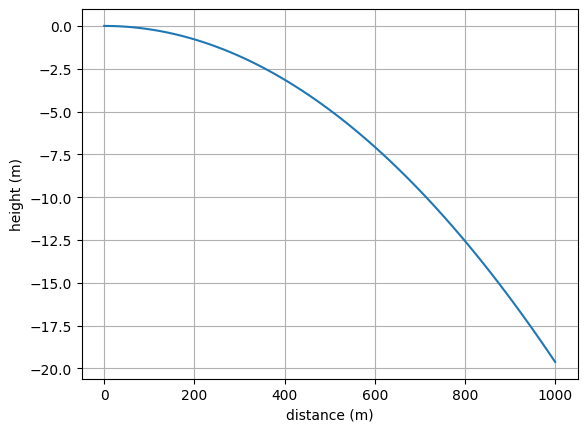

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

g = 9.81
v = 500
x = np.linspace(0, 1000, 100)
y = -g * x**2 / 2 / v**2

plt.plot(x, y);
plt.xlabel('distance (m)');
plt.ylabel('height (m)');
plt.grid();

### Exercise 3

Plot the first 6 so-called [Chebyshev polynomials](https://en.wikipedia.org/wiki/Chebyshev_polynomials) over the interval $[-1, 1]$:

> $T_0(x) = 1$

> $T_1(x) = x$

> $T_2(x) = 2x^2 - 1$

> $T_3(x) = 4x^3 - 3x$

> $T_4(x) = 8x^4 - 8x^2 + 1$

> $T_5(x) = 16x^5 - 20x^3 + 5x$

Plot all polynomials on the same graph. Add a legend and label the axes. Add a grid as well.

#### Solution

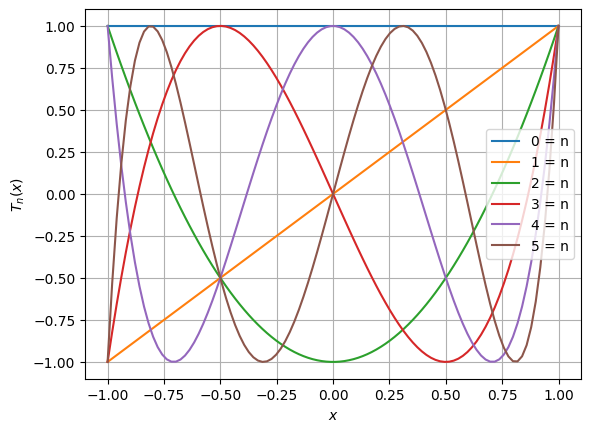

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

T = [[1],
     [1, 0],
     [2, 0, -1],
     [4, 0, -3, 0],
     [8, 0, -8, 0, 1],
     [16, 0, -20, 0, 5, 0]]

x = np.linspace(-1, 1, 100)
y = []
for coef in T:
    y.append(np.polyval(coef, x))

plt.plot(x, np.array(y).T);
plt.xlabel('$x$');  # use $...$ for LaTeX
plt.ylabel('$T_n(x)$');  # use $...$ for LaTeX
plt.grid();
plt.legend([str(i) + ' = n' for i in range(len(T))]);

## Polynomial Regression

The following exercises are about finding the most accurate polynomial to fit a dataset. In this section, the problem of overfitting is not yet addressed!

### Exercise 4

Read the file "Ice_cream selling data.csv" into a Pandas DataFrame. The file can also be downloaded from [Kaggle](https://www.kaggle.com/datasets/mirajdeepbhandari/polynomial-regression). Explore the dataset by using DataFrame methods `info` and `describe`, and make a scatter plot of the data.

Fit the data using a quadratic function with NumPy and Scikit-Learn. Apply the NumPy functions `polyfit` and `polyval` and Scikit-Learn classes `PolynomialFeatures` and `LinearRegression` to do so. Evaluate the two models using Scikit-Learn function `mean_absolute_error` and compare the results.

Use both models to predict the ice cream sale when it is -3°C and 3°C. Do you get the same result?

Finally, add the regression curves predicted by both models to the scatter plot. Also add the new data points. Make your plot look nice!

#### Solution

In [67]:
# import statements
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error as MAE
import matplotlib.pyplot as plt

In [68]:
# read file into pandas dataframe
df = pd.read_csv("Ice_cream selling data.csv")
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [69]:
# get dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [70]:
# calculate summary statistics
df.describe().T  # T transposes the table

,count,mean,std,min,25%,50%,75%,max
Temperature (°C),49.0,0.271755,2.697672,-4.662263,-2.111870,0.688781,2.784836,4.899032
Ice Cream Sales (units),49.0,15.905308,12.264682,0.328626,4.857988,12.615181,25.142082,41.842986


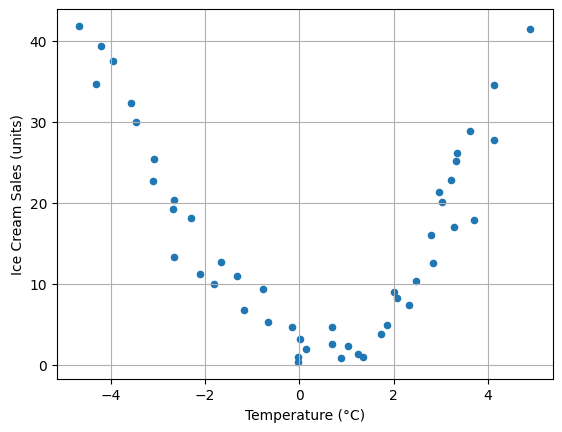

In [71]:
# create a scatter plot of the data
xlabel, ylabel = tuple(df.columns)
df.plot.scatter(xlabel, ylabel, grid=True);

In [72]:
# fit the data using a polynomial of degree 2 (= quadratic) with NumPy
x, y = df[xlabel].values, df[ylabel].values
coef = np.polyfit(x, y, deg=2)
MAE(y, np.polyval(coef, x))

2.6971548466037953

In [73]:
# fit the data using a polynomial of degree 2 (= quadratic) with Scikit-Learn
poly = PolynomialFeatures(degree=2, include_bias=False)
X = poly.fit_transform(x[:, np.newaxis])
model = LinearRegression()
model.fit(X, y)
MAE(y, model.predict(X))

2.6971548466037953

In [74]:
# use both models to predict the ice cream sale for -3°C and 3°C
xnew = np.array([-3, 3])
yp_np = np.polyval(coef, xnew)
print(yp_np)
yp_sk = model.predict(poly.fit_transform(xnew[:, np.newaxis]))

print(yp_sk)

[21.89155524 16.94346521]
[21.89155524 16.94346521]


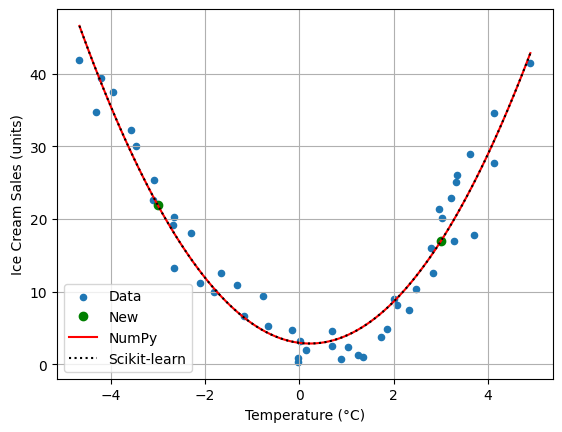

In [75]:
# calculate the regression curves predicted by both models
xcurve = np.linspace(x.min(), x.max(), 100)
ycurve_np = np.polyval(coef, xcurve)
ycurve_sk = model.predict(poly.fit_transform(xcurve[:, np.newaxis]))

# create scatter plot with regression curves and new data
ax = df.plot.scatter(xlabel, ylabel, label="Data", grid=True);  # training data
ax.plot(xnew, yp_np, 'go', label="New");  # new data
for ycurve, label, style in zip([ycurve_np, ycurve_sk],
                                 ['NumPy', 'Scikit-learn'],
                                 ['r-', 'k:']):
    ax.plot(xcurve, ycurve, style, label=label);  # regression curves
ax.legend();

### Exercise 5

Read file "zwift2.csv" into a Pandas DataFrame. Explore the data and create a scatter plot. Add a column to the DataFrame with the square of the times.

Use Scikit-Learn to fit the data by applying simple linear regression and quadratic regression. Calculate MAE and R². Which model performs best?

Predict the distance after 2 hours of cycling using both models. Add the regression line and curve which are predicted by the two respective models and extrapolated to this point in time to the scatter plot. Make your plot look nice.

#### Solution

In [100]:
# import statements
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error as MAE
import matplotlib.pyplot as plt

In [101]:
# read the file
df = pd.read_csv("zwift2.csv")
df.head()

,time (min),distance (km)
0,0,0.00
1,1,0.92
2,2,0.37
3,3,1.30
4,4,2.12


In [102]:
# get info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time (min)     61 non-null     int64  
 1   distance (km)  61 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [103]:
# get statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
time (min),61.0,30.000000,17.752934,0.0,15.00,30.00,45.00,60.00
distance (km),61.0,14.081803,7.644994,0.0,7.39,14.43,21.45,25.49


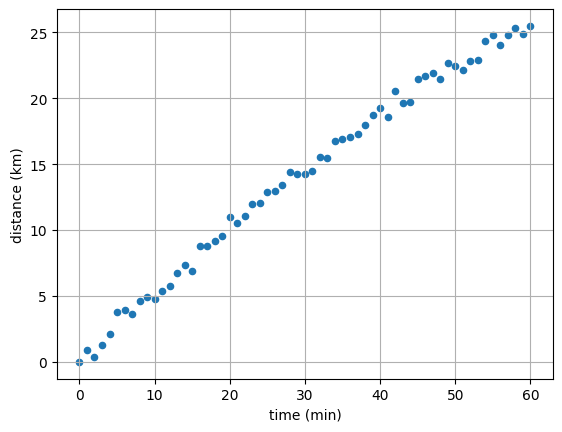

In [104]:
# make scatter plot
time, distance = tuple(df.columns)
df.plot.scatter(time, distance, grid=True);

In [105]:
# add column with time**2
time2 = 'time**2'
df[time2] = df[time] ** 2
df.head()

,time (min),distance (km),time**2
0,0,0.00,0
1,1,0.92,1
2,2,0.37,4
3,3,1.30,9
4,4,2.12,16


In [106]:
# simple linear regression

X1 = df[[time]]
y = df[distance]

model1 = LinearRegression()
model1.fit(X1, y)

yp1 = model1.predict(X1)
print(f"MAE = {MAE(y, yp1):.4f}")
print(f"R² = {model1.score(X1, y):.4f}")

MAE = 0.6154
R² = 0.9904


In [108]:
# quadratic regression - which clearly performs better!

X2 = df[[time, time2]]

model2 = LinearRegression()
model2.fit(X2, y)

yp2 = model2.predict(X2)
print(f"MAE = {MAE(y, yp2):.4f}")
print(f"R² = {model2.score(X2, y):.4f}")

MAE = 0.3666
R² = 0.9964


In [116]:
# predict distance after 2 hours = 120 min

tnew = 2 * 60
Xnew = pd.DataFrame({time : [tnew], time2 : [tnew**2]})

ynew1 = model1.predict(Xnew[[time]])
ynew2 = model2.predict(Xnew[[time, time2]])

for name, ynew in zip(['Linear regression', 'Quadratic regression'], [ynew1, ynew2]):
    print(f"{name}: distance after {tnew} min = {ynew[0]:.2f} km")

Linear regression: distance after 120 min = 52.65 km
Quadratic regression: distance after 120 min = 36.07 km


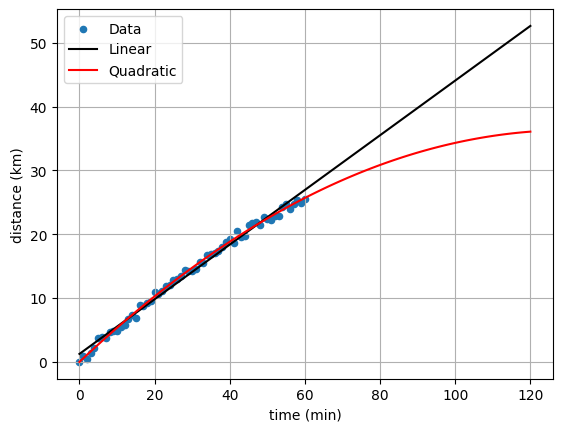

In [117]:
# add regression curves to scatter plot

tcurve = np.linspace(0, tnew, 100)
Xcurve = pd.DataFrame({time : tcurve, time2 : tcurve**2})
ycurve1 = model1.predict(Xcurve[[time]])
ycurve2 = model2.predict(Xcurve[[time, time2]])

ax = df.plot.scatter(time, distance, label="Data", grid=True);
for name, ycurve, style in zip(['Linear', 'Quadratic'], [ycurve1, ycurve2], ['k-', 'r-']):
    ax.plot(tcurve, ycurve, style, label=name);
ax.legend();

### Exercise 6

Read the file "poly_reg.csv" into a Pandas DataFrame. The data in this file was generated according to the following polynomial:

> $y = -x^3 - x^2 + 2x$

Try to fit this polynomial again. Use NumPy's `polyfit` function and Scikit-Learn. Check the coefficients and calculate MAE, MSE and R² for both cases. Do you get the same result?

Finally, plot the data in a scatterplot together with the actual polynomial and the polynomial obtained from the polynomial regression. Make your graph look nice.

#### Solution

In [118]:
# import statements
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [119]:
# file inlezen
df = pd.read_csv("poly_reg.csv")
df.describe()

,Unnamed: 0,X,y
count,25.000000,25.000000,25.000000
mean,12.000000,-0.500000,-0.024844
std,7.359801,1.533292,4.432472
min,0.000000,-3.000000,-8.999078
25%,6.000000,-1.750000,-2.251639
50%,12.000000,-0.500000,-0.852045
75%,18.000000,0.750000,0.820023
max,24.000000,2.000000,11.586012


In [120]:
# X and y
x = df.X.values  # 1D array
X = x.reshape(-1, 1)  # 2D array
y = df.y.values  # 1D array

In [121]:
# real polynomial
coef = np.array([-1, -1, 2, 0])
x_true = np.linspace(x.min(), x.max(), 100)
y_true = np.polyval(coef, x_true)

In [122]:
# polyfit
coef_np = np.polyfit(x, y, deg=3)
coef_np

array([-0.9897988 , -0.80430315,  1.93764282, -0.51428526])

In [123]:
# polyfit: MAE, MSE, R²
y_np = np.polyval(coef_np, x)  # predictions
MAE_np = mean_absolute_error(y, y_np)
MSE_np = mean_squared_error(y, y_np)
R2_np = r2_score(y, y_np)
print("MAE =", MAE_np)
print("MSE =", MSE_np)
print("R² =", R2_np)

MAE = 0.8481974906425475
MSE = 1.0103780365925636
R² = 0.9464301278952488


In [124]:
# sklearn fit
model = make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression())  # set include_bias to False!
model.fit(X, y)
coef_sk = np.insert(model.steps[1][1].coef_, 0, model.steps[1][1].intercept_)
coef_sk  # gives the same coefficients, only they are now ordered from low to high

array([-0.51428526,  1.93764282, -0.80430315, -0.9897988 ])

In [125]:
# compare the coefficients
np.vstack((coef_np[::-1], coef_sk))

array([[-0.51428526,  1.93764282, -0.80430315, -0.9897988 ],
       [-0.51428526,  1.93764282, -0.80430315, -0.9897988 ]])

In [126]:
# sklearn fit: MAE, MSE, R²
y_sk = model.predict(X)  # predictions
MAE_sk = mean_absolute_error(y, y_sk)
MSE_sk = mean_squared_error(y, y_sk)
R2_sk = r2_score(y, y_sk)
print("MAE =", MAE_sk)
print("MSE =", MSE_sk)
print("R² =", R2_sk)

MAE = 0.8481974906425473
MSE = 1.0103780365925632
R² = 0.9464301278952488


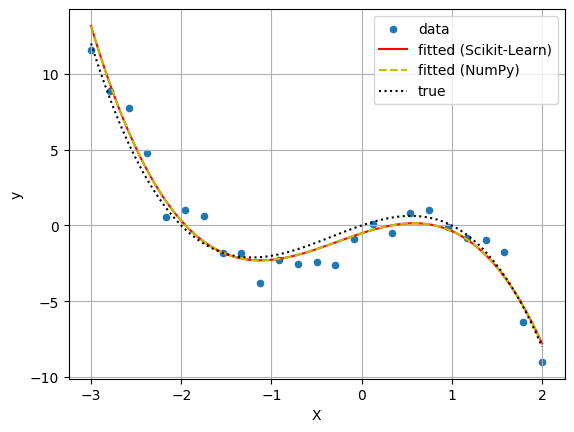

In [127]:
# plot
ax = df.plot.scatter('X', 'y', label="data", grid=True);
y_fit_sk = model.predict(x_true.reshape(-1, 1))  # predictions for sklearn regression curve
y_fit_np = np.polyval(coef_np, x_true)           # predictions for numpy regression curve
ax.plot(x_true, y_fit_sk, 'r-', label="fitted (Scikit-Learn)");
ax.plot(x_true, y_fit_np, 'y--', label="fitted (NumPy)");
ax.plot(x_true, y_true, 'k:', label="true");
plt.legend();

### Exercise 7

Read the file "china_gdp.csv" with China's [Gross Domestic Product](https://en.wikipedia.org/wiki/Gross_domestic_product) (GDP) for the period 1960 to 2014.

Try to fit the curve as accurate as possible. Make a scatterplot of the data and add the obtained regression curve to it. You do not need to validate or apply regularization.

Tip: rescale the years and apply a logarithmic transformation to the values of the GDP.

Can you use the regression model to predict how much China's GDP will be in 2050? Explain!

#### Solution

In [42]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

We read the file "china_gdp.csv":

In [43]:
gdp = pd.read_csv("china_gdp.csv", skiprows=2)
gdp.head()

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10


We make a scatterplot:

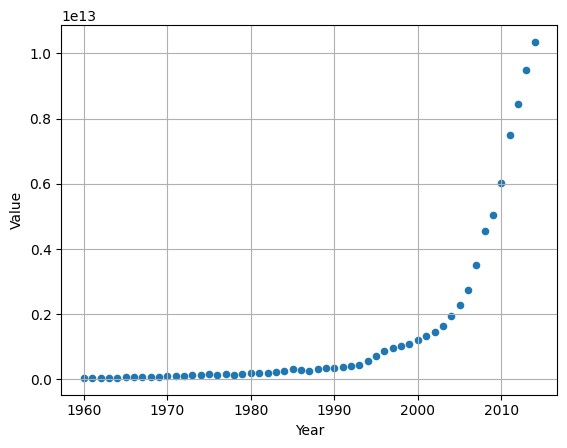

In [44]:
gdp.plot.scatter(x="Year", y="Value", grid=True);

These are gigantic numbers, because this is in US Dollar. In such cases, a logarithmic transformation is practical:

In [45]:
gdp['Log'] = np.log10(gdp.Value)
gdp.head()

,Year,Value,Log
0,1960,5.918412e+10,10.772205
1,1961,4.955705e+10,10.695105
2,1962,4.668518e+10,10.669179
3,1963,5.009730e+10,10.699814
4,1964,5.906225e+10,10.771310


The scatterplot with logarithmic values:

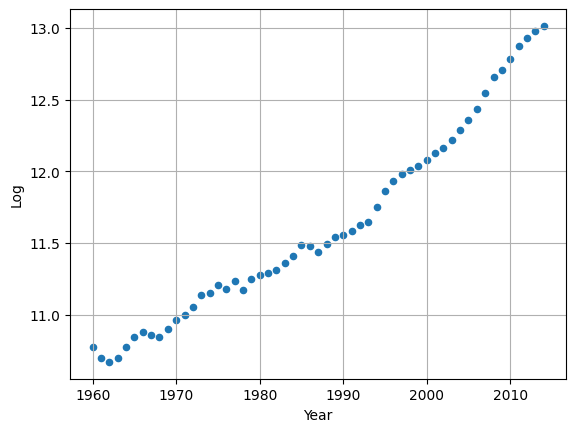

In [46]:
gdp.plot.scatter(x="Year", y="Log", grid=True);

Simple linear regression would probably not do badly here, but let's see if we can do better by applying polynomial regression. We will use polynomials of different degrees and, to be able to compare the different models afterwards, we will calculate the MAE as an evaluation metric each time. To make everything run efficiently, we will of course make use of a loop.

In [50]:
x = gdp.Year.values.squeeze() - 1960
z = gdp.Log.values.squeeze()

degrees = range(1, 21)

MAE = []
for deg in degrees:
    coef = np.polyfit(x, z, deg)
    zp = np.polyval(coef, x)
    MAE.append(np.mean(np.abs(z - zp)))

<ipython-input-50-8161d6000588>:8: RankWarning: Polyfit may be poorly conditioned
  a = np.polyfit(x, z, deg)
<ipython-input-50-8161d6000588>:8: RankWarning: Polyfit may be poorly conditioned
  a = np.polyfit(x, z, deg)


We see that the `polyfit` function gives a warning for the last 2 fits. Without going into the mathematical details, that warning means that the fit is not that good.

Let's plot the result now:

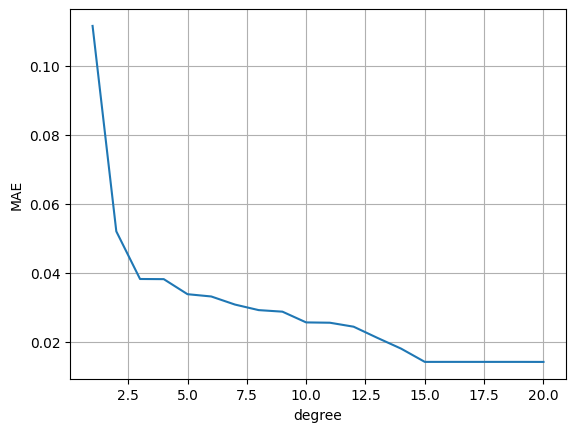

In [51]:
plt.plot(degrees, MAE);
plt.xlabel("degree");
plt.ylabel("MAE");
plt.grid();

From degree 15 onwards, we no longer see much improvement, so we finally choose the regression with a polynomial of degree 15. We must also not forget to convert the logarithmically transformed predictions back to USD values:

> $z = \log(y) \iff y = 10^z$

with $z$ the logarithmically transformed targets.

In [52]:
coef = np.polyfit(x, z, deg=15)
zp = np.polyval(coef, x)
yp = 10 ** zp  # do not forget to convert the predictions back!

When we add the obtained regression curve to the scatterplot with data, it looks very good!

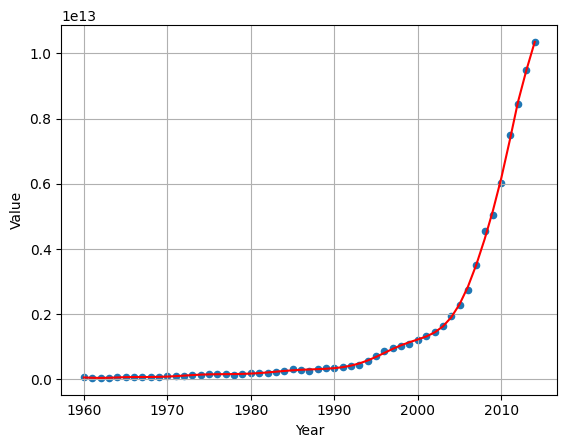

In [53]:
ax = gdp.plot.scatter(x="Year", y="Value", grid=True);
ax.plot(x + 1960, yp, 'r-');

Now we can predict the Chinese GDP for the coming years, for example, up to 2050:

<ipython-input-59-f18d9bf2d04a>:2: RuntimeWarning: overflow encountered in power
  bbp = 10 ** np.polyval(coef, years - 1960)  # don't forget to scale the years!


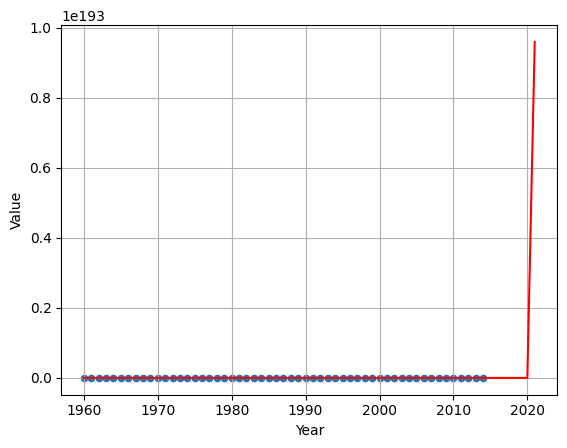

In [59]:
years = np.arange(1960, 2051)
bbp = 10 ** np.polyval(coef, years - 1960)  # don't forget to scale the years!

ax = gdp.plot.scatter(x="Year", y="Value", grid=True);
ax.plot(years, bbp, 'r-');

That doesn't look realistic because we've used the model to **extrapolate**, and as we see, that involves risks, especially when we use high-degree polynomials! Moreover, this is about a **time series**, a series of data with time as the index. The order of the data points is important here, and we don't take that into account with linear and polynomial regression!

### Exercise 8

The file "GDP.csv" contains the GDP per capita in USD for a whole range of countries for the period 1960 to 2021. Read in the file, pick a country out (e.g. France), and try to fit the time series as well as possible using a polynomial.

#### Solution

In [60]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

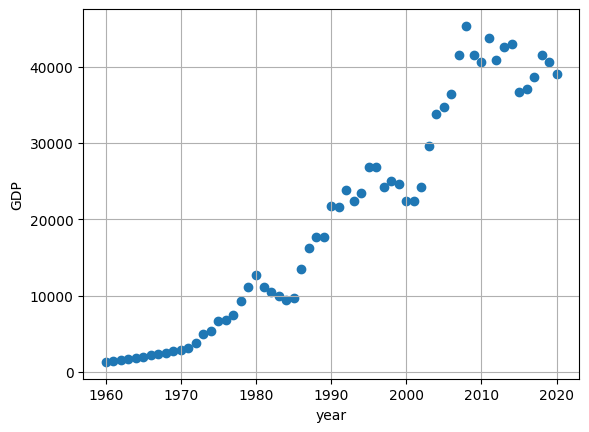

In [62]:
# read file and select data for France

gdp = pd.read_csv("GDP.csv", skiprows=4)
year = np.arange(1960, 2021)
amount = gdp.loc[gdp['Country Name']=="France", :].iloc[:, 4:-1].values.squeeze()

plt.scatter(year, amount);
plt.xlabel("year");
plt.ylabel("GDP");
plt.grid();

In [63]:
# fit transformed series with different polynomials

x = year - 1960  # subtract 1960 from year
z = np.log10(amount)  # take log10 of gdp

degrees = range(1, 21)  # let degrees vary from 1 to 20

MAE = []  # calculate mean absolute error
for deg in degrees:
    coef = np.polyfit(x, z, deg)
    zp = np.polyval(coef, x)
    MAE.append(np.mean(np.abs(z - zp)))

<ipython-input-63-d4fe4d37447a>:10: RankWarning: Polyfit may be poorly conditioned
  a = np.polyfit(x, z, deg)
<ipython-input-63-d4fe4d37447a>:10: RankWarning: Polyfit may be poorly conditioned
  a = np.polyfit(x, z, deg)


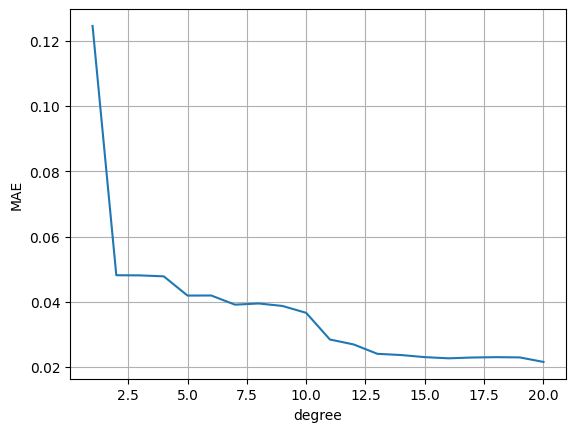

In [65]:
# plot of MAE vs degree
plt.plot(degrees, MAE);
plt.xlabel("degree");
plt.ylabel("MAE");
plt.grid();

In [66]:
# no improvement from deg = 16 (+ last degrees are not reliable)
coef = np.polyfit(x, z, deg=16)
zp = np.polyval(coef, x)
yp = 10 ** zp  # don't forget to convert the predictions back!

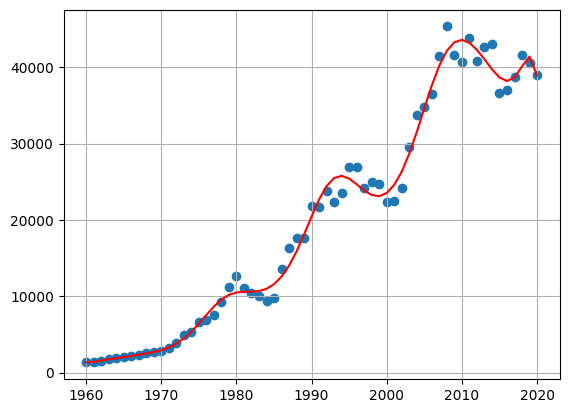

In [67]:
# scatterplot with regression curve
plt.scatter(year, amount);
plt.plot(x + 1960, yp, 'r-');  # do not forget to add 1960 to x!
plt.grid();

## Underfitting and overfitting

In the exercises of this section, the goal is to find a polynomial that neither underfits nor overfits the data. The two techniques we will apply for this are the **model complexity graph** and **regularization**, namely Lasso and Ridge. **Splitting the dataset** into training, validation, and test sets will also be covered, as well as applying **cross-validation**, which is particularly interesting for small datasets.

### Exercise 9

Read the file "poly_reg.csv" again into a Pandas DataFrame. Recall the data points were generated according to the following polynomial:

> $y = -x^3 - x^2 + 2x$

Try to fit this full dataset again by applying **Lasso and Ridge regression**, assuming a polynomial of degree 6. Check the coefficients and calculate MAE and MSE for both cases. Do you get a better result than in exercise 6?

Plot the data points together with the true polynomial and the polynomial obtained from both regressions. Make your graph look nice.

#### Solution

In [1]:
# import statements
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
# file inlezen
df = pd.read_csv("poly_reg.csv")
df.head()

,Unnamed: 0,X,y
0,0,-3.000000,11.586012
1,1,-2.791667,8.885560
2,2,-2.583333,7.716772
3,3,-2.375000,4.771019
4,4,-2.166667,0.547357


In [4]:
# X and y
X = df.X.values.reshape(-1, 1)  # 2D array
y = df.y.values  # 1D array

In [6]:
# real polynomial
coef = np.array([-1, -1, 2, 0])
x_true = np.linspace(X.min(), X.max(), 100)
y_true = np.polyval(coef, x_true)

In [7]:
# Applying Lasso and Ridge regression

degree = 6  # polynomial of degree 6

lasso = make_pipeline(PolynomialFeatures(degree, include_bias=False), Lasso(alpha=0.1, tol=0.1))  # bias not needed!
lasso.fit(X, y);

ridge = make_pipeline(PolynomialFeatures(degree, include_bias=False), Ridge(alpha=0.1, tol=0.1))  # bias not needed!
ridge.fit(X, y);

In [8]:
# Mean Absolute Error and Mean Squared Error
# Lasso does it a bit less well than the degree 3 polynomial fit in pervious exercise ...
# Ridge does it a bit better!

y_lasso = lasso.predict(X)  # lasso predictions
y_ridge = ridge.predict(X)  # ridge predictions

print("Mean Absolute Error lasso:", mean_absolute_error(y, y_lasso))
print("Mean Squared Error lasso", mean_squared_error(y, y_lasso))

print("Mean Absolute Error ridge:", mean_absolute_error(y, y_ridge))
print("Mean Squared Error ridge", mean_squared_error(y, y_ridge))

Mean Absolute Error lasso: 0.9724422634501565
Mean Squared Error lasso 1.306779363658604
Mean Absolute Error ridge: 0.5772145131555936
Mean Squared Error ridge 0.5325826840347279


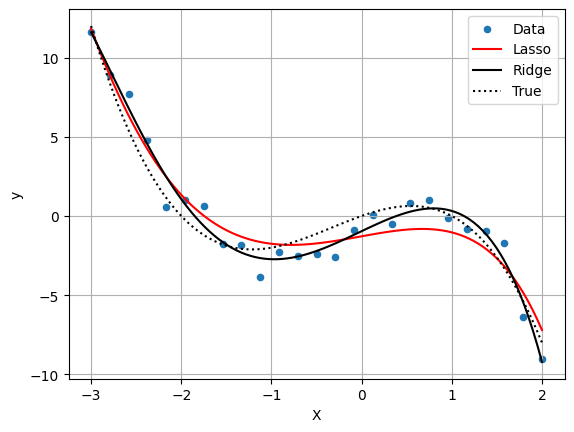

In [11]:
# predictions
y_lasso = lasso.predict(x_true.reshape(-1, 1))  # lasso regression curve
y_ridge = ridge.predict(x_true.reshape(-1, 1))  # ridge regression curve

# plot
ax = df.plot.scatter('X', 'y', label="Data", grid=True);
for y, label, style in zip([y_lasso, y_ridge, y_true],
                           ['Lasso', 'Ridge', 'True'],
                           ['r-', 'k-', 'k:']):
    ax.plot(x_true, y, style, label=label);
ax.legend();

### Exercise 10

Read the file "loon_vs_geluk.json" with (fictional) data that represents the relationship between someone's salary (in Dutch: loon) and happiness (in Dutch: geluk). The gross annual salary has a unit of 10,000 euros. The happiness is expressed as a score from 0 to 10.

Plot the data and apply polynomial regression. Select the best model based on a **model complexity graph**. Split your dataset into 3 parts so that you can also test the selected model. Take 400 data points for the training set and 400 for the validation set. This is called **simple hold-out validation**. The remaining data points form the test set.

Retrain the final model on the entire dataset and plot the result.

#### Solution

In [21]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as matplotlib_pyplot

In [22]:
# read file
df = pd.read_json('loon_vs_geluk.json', orient='table');
xlabel, ylabel = 'salary', 'happiness'
df.rename(columns={'jaarloon': xlabel, 'gelukscore': ylabel}, inplace=True)
df.head()

,salary,happiness
0,1.0000,0.0
1,1.0180,0.8
2,1.0360,1.1
3,1.0541,1.8
4,1.0721,0.3


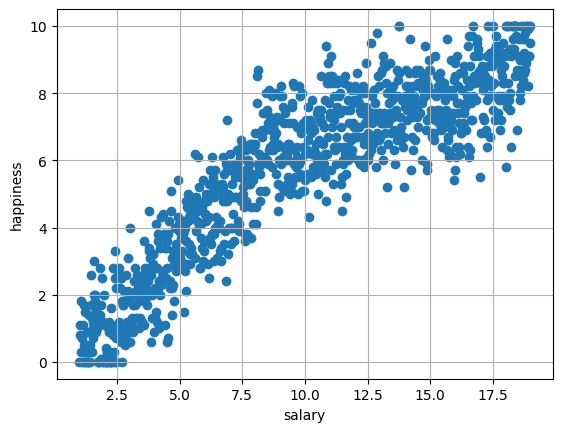

In [23]:
# convert features to numpy arrays and make scatterplot
x_data = df[xlabel].values
y_data = df[ylabel].values
plt.scatter(x_data, y_data);
plt.xlabel(xlabel);
plt.ylabel(ylabel);
plt.grid();

In [30]:
# dataset splitting
idx = list(range(len(x_data)))  # indices of data points
np.random.seed(22)
np.random.shuffle(idx)
train_idx, val_idx, test_idx = idx[:400], idx[400:800], idx[800:]
train_val_idx = idx[:800]

In [28]:
# create model complexity graph

MAE_train = []
MAE_val = []

degrees = range(1, 16)
for deg in degrees:
    coef = np.polyfit(x_data[train_idx], y_data[train_idx], deg)  # training set only!!
    y_pred_train = np.polyval(coef, x_data[train_idx])
    MAE_train.append(np.mean(np.abs(y_data[train_idx] - y_pred_train)))
    y_pred_val = np.polyval(coef, x_data[val_idx])
    MAE_val.append(np.mean(np.abs(y_data[val_idx] - y_pred_val)))

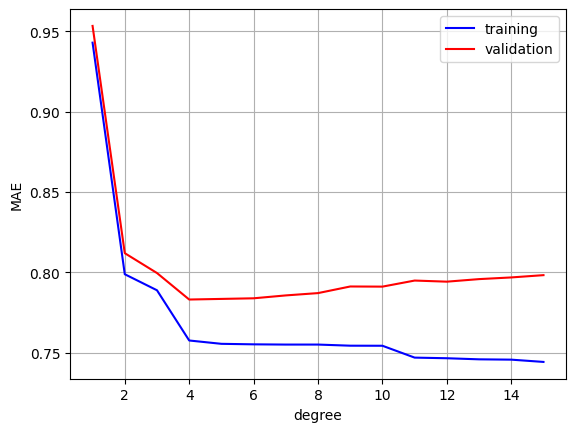

In [29]:
# plot model complexity graph
plt.plot(degrees, MAE_train, 'b-', degrees, MAE_val, 'r-');
plt.xlabel('degree')
plt.ylabel('MAE')
plt.grid();
plt.legend(['training', 'validation']);

In [33]:
# we choose n = 4 and perform final test
coef = np.polyfit(x_data[train_val_idx], y_data[train_val_idx], deg=4)  # training + validation set!!
y_pred_test = np.polyval(coef, x_data[test_idx])
np.mean(np.abs(y_data[test_idx] - y_pred_test))

0.8050308683430145

In [34]:
# Mean Absolute Error of test set ok -> final model training with full dataset!
coef = np.polyfit(x_data, y_data, deg=4)
y_pred = np.polyval(coef, x_data)
np.mean(np.abs(y_data - y_pred))

0.7753896317326798

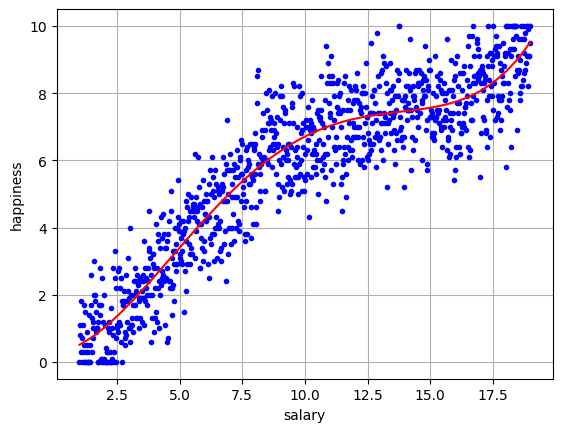

In [35]:
# final plot
x_curve = np.linspace(x_data.min(), x_data.max(), 500)
y_curve = np.polyval(coef, x_curve)
plt.plot(x_data, y_data, 'b.', x_curve, y_curve, 'r-');
plt.xlabel(xlabel);
plt.ylabel(ylabel);
plt.grid();

**Important** to take away from this exercise is how the different datasets are used:
1. The **training set** is used by the algorithm to derive the **parameters**.
2. During training, the **validation set** is used by the engineer to tune the **hyperparameters**, in this case, the degree of the polynomial function. This tuning is necessary to find a **balance between underfitting and overfitting**.
3. When the best-performing model is found, here a polynomial regression of degree 4, we re-train that model with the combined training and validation sets and perform a **final evaluation** using the **test set**.
4. If this final evaluation is satisfactory, we then train that model one last time with the **full dataset**.
5. The **final model** is then **deployed** and used in a production environment to make predictions with new data.

### Exercise 11

Read the file "loon_vs_geluk.json" again and apply **Lasso and Ridge regression** to the full dataset, taking a polynomial of degree 10. Calculate the MAE and plot the result.

Do you get a better solution than in the previous exercise 10?

#### Solution

In [36]:
# import statements
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error as MAE
import matplotlib.pyplot as plt

In [37]:
# read file
df = pd.read_json('loon_vs_geluk.json', orient='table');
xlabel, ylabel = 'salary', 'happiness'
df.rename(columns={'jaarloon': xlabel, 'gelukscore': ylabel}, inplace=True)
df.head()

,salary,happiness
0,1.0000,0.0
1,1.0180,0.8
2,1.0360,1.1
3,1.0541,1.8
4,1.0721,0.3


In [40]:
# convert features to numpy arrays
X = df[[xlabel]].values  # 2D matrix
y = df[ylabel].values    # 1D vector

In [41]:
# Applying Lasso and Ridge regression

degree = 10  # polynomial of degree 10

lasso = make_pipeline(PolynomialFeatures(degree, include_bias=False),  # bias not needed!
                      Lasso(alpha=0.1, tol=0.1))
lasso.fit(X, y);

ridge = make_pipeline(PolynomialFeatures(degree, include_bias=False),  # bias not needed!
                      Ridge(alpha=0.1, tol=0.1))
ridge.fit(X, y);

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.22565e-29): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [42]:
# Calculate Mean Absolute Error
# Ridge performs equally well as our polynomial degree 4 from previous exercise
# Lasso does not perform well here

print("MAE Lasso:", MAE(y, lasso.predict(X)))
print("MAE Ridge:", MAE(y, ridge.predict(X)))

MAE Lasso: 0.8950884315265368
MAE Ridge: 0.7731238015480294


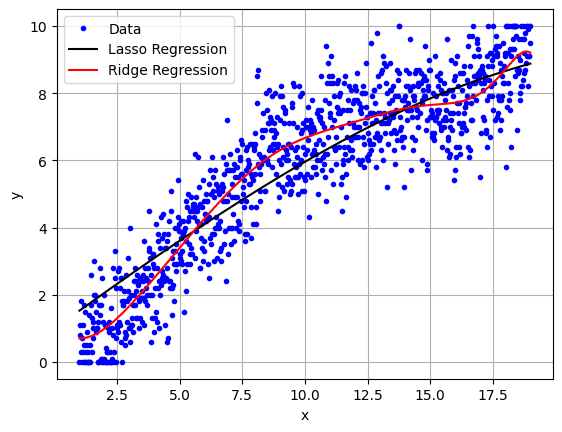

In [44]:
# plot: confirms that Ridge performs equally well and Lasso performs less well

x_curve = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_lasso = lasso.predict(x_curve)
y_ridge = ridge.predict(x_curve)

plt.plot(X, y, 'b.', x_curve, y_lasso, 'k-', x_curve, y_ridge, 'r-');
plt.xlabel('x');
plt.ylabel('y');
plt.grid();
plt.legend(['Data', 'Lasso Regression', 'Ridge Regression']);

### Exercise 12

Read the file "Student_Marks.csv" into a Pandas DataFrame, explore the data, and make a scatter plot of "Marks" as a function of "time_study".

Apply polynomial regression to fit the data using NumPy functions `polyfit` and `polyval`. Shuffle the samples and split the dataset in 5 folds of 20 samples each. Apply cross-validation with the first 4 folds to construct a model complexity graph based on the MAE. Determine the optimal degree of the polynomial regression. Use the remaining fold as test set.

The goal of this exercise is to gain a good understanding of how **K-fold cross-validation** works. Therefore, do not use Scikit-Learn but try to program everything yourself using NumPy. In the next exercise, we'll solve the same problem using Scikit-Learn.

#### Solution

In [10]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# read the file into a dataframe
df = pd.read_csv("Student_Marks.csv")
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [19]:
# get dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


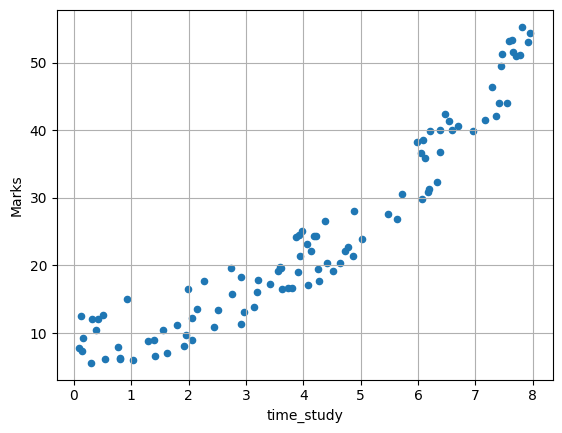

In [20]:
# create scatter plot
df.plot.scatter("time_study", "Marks", grid=True);

In [21]:
# shuffle rows (and set random seed to get same result)
np.random.seed(0)
df = df.sample(frac=1).reset_index(drop=True)

In [22]:
# create 5 random folds

n_samples = len(df)       # total number of samples
n_folds = 5               # total number of folds
m = n_samples // n_folds  # number of samples in each fold
j = np.arange(m)          # indices 0 to 19

# create 5 new dataframes of 20 samples and store them in list folds
folds = []
for i in range(n_folds):
    folds.append(df.iloc[i*m+j, :])

df_test = folds[-1]  # last fold is test set
folds = folds[:-1]   # first 4 folds will be used in cross-validation

In [23]:
# construct the model complexity graph using cross-validation

# function to calculate MAE
MAE = lambda y_true, y_pred: np.mean(np.abs(y_true - y_pred))

# we calculate the average MAE for training and validation set
MAE_train_avg = []
MAE_val_avg = []

# we check degrees from 1 to 15
degrees = np.arange(1, 16)
for deg in degrees:

    # we calculate MAE for training and validation set during each cross-validation run
    MAE_train = []
    MAE_val = []
    for k in range(n_folds - 1):

        # validation set is fold k
        df_val = folds[k]
        x_val, y_val = df_val.time_study, df_val.Marks

        # concatentate remaining folds to get training set
        df_train = pd.concat(folds[:k] + folds[k+1:])
        x_train, y_train = df_train.time_study, df_train.Marks

        # fit polynomial regression
        coef = np.polyfit(x_train, y_train, deg=deg)

        # predictions for samples in training and validation set
        yp_train = np.polyval(coef, x_train)
        yp_val = np.polyval(coef, x_val)

        # calculate MAE for training and validation set
        MAE_train.append(MAE(y_train, yp_train))
        MAE_val.append(MAE(y_val, yp_val))

    # calculate average MAE for training and validation of the 4 cross-validation runs
    MAE_train_avg.append(np.mean(MAE_train))
    MAE_val_avg.append(np.mean(MAE_val))

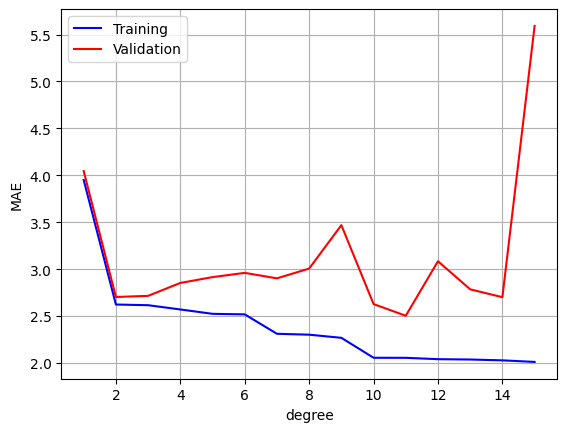

In [24]:
# plot the model complexity graph using the average MAE for training and validation
plt.plot(degrees, MAE_train_avg, 'b-', degrees, MAE_val_avg, 'r-');
plt.xlabel("degree");
plt.ylabel("MAE");
plt.legend(['Training', 'Validation'])
plt.grid();

In [26]:
# look at the validation curve in the model complexity graph to get the optimal degree

# fit polynomial of degree 2 using the first 4 folds
df_train = pd.concat(folds)
x_train, y_train = df_train.time_study, df_train.Marks
coef = np.polyfit(x_train, y_train, deg=2)

# test model
x_test, y_test = df_test.time_study, df_test.Marks
yp_test = np.polyval(coef, x_test)
MAE_test = MAE(y_test, yp_test)
print("MAE test:", np.round(MAE_test, 2))

MAE test: 2.45


In [27]:
# the MAE for the test set is acceptable

# perform final training using the full dataset
x, y = df.time_study, df.Marks
coef = np.polyfit(x, y, deg=2)

# evaluate final model
yp = np.polyval(coef, x)
print("MAE final:", np.round(MAE(y, yp), 2))

MAE final: 2.59


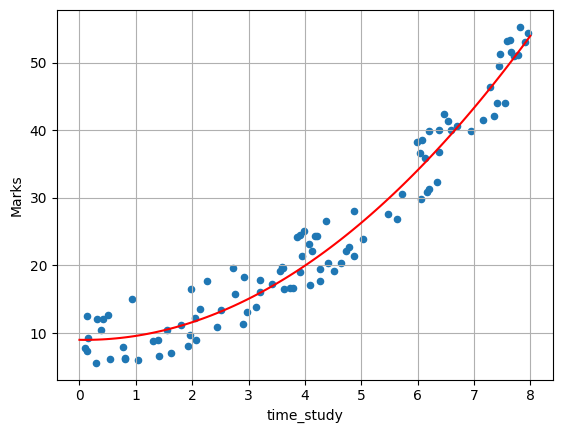

In [28]:
# the final model still performs well, so it is accepted
# make final scatter plot showing the regression curve predicted by the final model
ax = df.plot.scatter("time_study", "Marks", grid=True);
x_curve = np.linspace(0, 8, 100)
y_curve = np.polyval(coef, x_curve)
ax.plot(x_curve, y_curve, 'r-');

### Exercise 13

Read the file "Student_Marks.csv" again into a Pandas DataFrame. Do the same as in the previous exercise 12, but this time using Scikit-Learn:

- Use function `train_test_split` to split the dataset in a training set (80%) and a test set (20%).
- Use classes `PolynomialFeatures` and `LinearRegression` to apply polynomial regression and predict "Marks" based on "time_study". Function `make_pipeline` may be useful to combine both classes into one pipeline.
- Use function `cross_validate` to perform the cross validation with 4 folds.
- Use functions `make_scorer` and `mean_absolute_error` to calculate the MAE for both training and validation.

#### Solution

In [77]:
# import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_absolute_error, make_scorer

In [78]:
# read file into dataframe
df = pd.read_csv("Student_Marks.csv")
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [79]:
# get feature and target and split dataset
xlabel, ylabel = "time_study", "Marks"
X, y = df[[xlabel]], df[ylabel]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [80]:
# construct the model complexity graph using cross-validation

# we calculate the average MAE for training and validation set
MAE_train_avg = []
MAE_val_avg = []

# we check degrees from 1 to 15
degrees = np.arange(1, 16)
for degree in degrees:

    # create polynomial regression pipeline
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())

    # apply cross validation and calculate MAE for training and validation
    result = cross_validate(model, X_train, y_train, cv=4,
                            scoring=make_scorer(mean_absolute_error), return_train_score=True)

    # calculate average MAE for training and validation
    MAE_train_avg.append(np.mean(result["train_score"]))
    MAE_val_avg.append(np.mean(result["test_score"]))

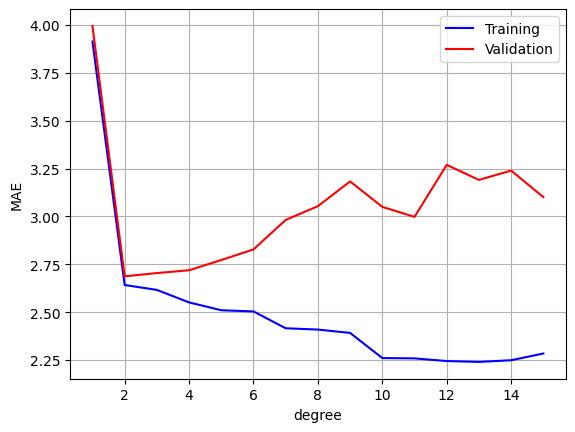

In [81]:
# plot the model complexity graph using the average MAE for training and validation
plt.plot(degrees, MAE_train_avg, 'b-', degrees, MAE_val_avg, 'r-');
plt.xlabel("degree");
plt.ylabel("MAE");
plt.legend(['Training', 'Validation'])
plt.grid();

In [84]:
# look at the validation curve in the model complexity graph to get the optimal degree

# fit polynomial of degree 2 using the first 4 folds
model = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
model.fit(X_train, y_train)

# test model
yp_test = model.predict(X_test)
MAE_test = mean_absolute_error(y_test, yp_test)
print("MAE test:", np.round(MAE_test, 2))

MAE test: 2.53


In [85]:
# the MAE for the test set is acceptable

# perform final training using the full dataset
model.fit(X, y)

# evaluate final model
yp = model.predict(X)
MAE = mean_absolute_error(y, yp)
print("MAE final:", np.round(MAE, 2))

MAE final: 2.59


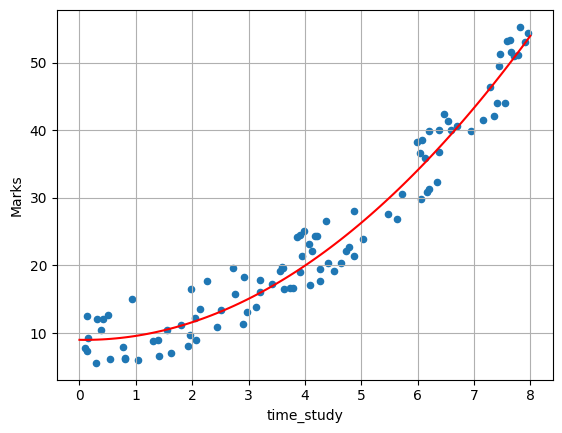

In [86]:
# the final model still performs well, so it is accepted
# make final scatter plot showing the regression curve predicted by the final model
ax = df.plot.scatter(xlabel, ylabel, grid=True);
X_curve = pd.DataFrame(np.linspace(0, 8, 100).reshape(-1, 1), columns=[xlabel])
y_curve = model.predict(X_curve)
ax.plot(X_curve, y_curve, 'r-');

Note that we do not get exactly the same solution here as in the previous exercise because the splitting of the dataset into training and test sets and the determination of the folds are done **randomly**! Here, the random state or seed was specified each time to get the same result after re-running the code, but in practice, you prefer not to do this to let the process happen truly randomly!

**Important** to take away from this exercise is how **cross-validation** works:
1. The dataset is split into a training set and test set.
2. The training set is split into **k folds**. Here, we used 4 folds.
3. The model is trained k times. During training k, the k-th fold is used as validation set, while the remaining folds form the training set.
4. During each training, a score is calculated for training and validation. Here, we used the MAE. At the end, the average of the k scores is calculated for both training and validation.
5. By comparing these average scores, the hyperparameters are tuned to overcome overfitting. Here, the model complexity graph was used to find the optimal polynomial degree.
6. When the best-performing model is found, here a polynomial regression of degree 2, we re-train that model with the combined training and validation sets and perform a final evaluation using the test set.
7. If this final evaluation is satisfactory, we then train that model one last time with the full dataset.
8. The final model is then deployed and used in a production environment to make predictions with new data.

### Exercise 14

Read the dataset "linkedIn.csv" into a Pandas dataframe. In the previous topic, we already fitted this data using simple linear regression. In this exercise, we will investigate whether we can achieve a better fit by applying quadratic regression. We will compare both models using **simple hold-out validation**. The best model will be finally evaluated using the test set.

Start by splitting your dataset as follows: take 500 random data points for the validation and test set; the remaining data points form the training set.

Apply simple linear regression and quadratic regression to the training set. Calculate the RMSE for the training and validation set each time. Which model do you choose?

Evaluate the chosen model with the test set. Do you get an equally good result? If yes, train your definitive model on the entire set and plot the result.

#### Solution

In [200]:
# import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

The dataset

In [201]:
# read file
df = pd.read_csv("linkedIn.csv")
ylabel, xlabel = "salary", "connections"
df.rename(columns={"loon": ylabel, "connecties": xlabel}, inplace=True)
df.head()

,salary,connections
0,3252,304
1,2968,216
2,2976,159
3,3255,273
4,1953,191


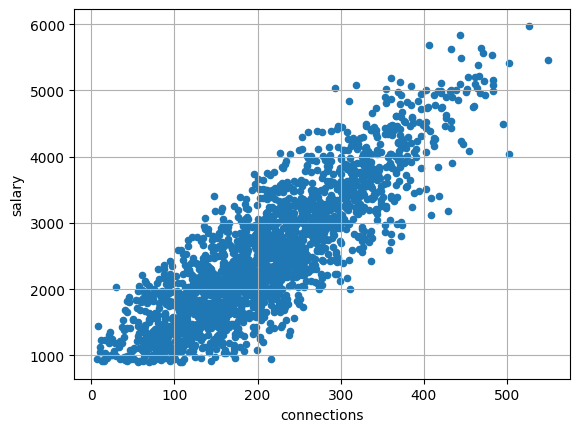

In [202]:
# make scatter plot
df.plot.scatter(x=xlabel, y=ylabel, grid=True);

Dataset splitting

In [203]:
# rows shuffling
np.random.seed(0)
df = df.sample(frac=1)

# feature and target
X = df[[xlabel]].values
y = df[ylabel].values

In [204]:
# splitting

n_test = 500
n_val = 500

X_test, y_test = X[:n_test], y[:n_test]
X_train, y_train = X[n_test:], y[n_test:]
X_val, y_val = X_train[:n_val], y_train[:n_val]
X_train, y_train = X_train[n_val:], y_train[n_val:]

X_train = X_train.reshape(-1, 1)
X_val = X_val.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(1064, 1) (1064,)
(500, 1) (500,)
(500, 1) (500,)


In [205]:
# can faster with function sklearn.model_selection.train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=n_test, random_state=25)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=n_val, random_state=25)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(1064, 1) (1064,)
(500, 1) (500,)
(500, 1) (500,)


Training and validation

Slope = 8.85
Intercept = 670.63
RMSE = 513.65


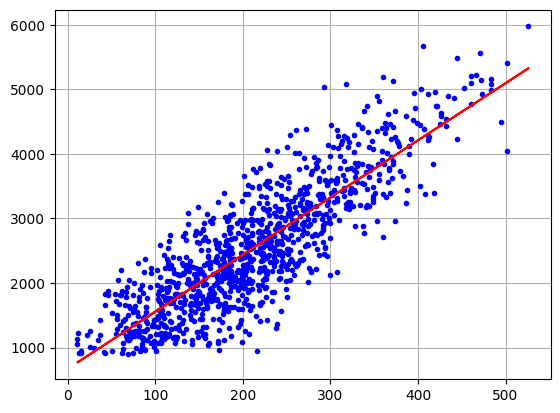

In [206]:
# linear regression

# train
lr = LinearRegression()  # instantiate
lr.fit(X_train, y_train)  # fit

# get parameters
print("Slope = {:.2f}".format(lr.coef_[0]))
print("Intercept = {:.2f}".format(lr.intercept_))

# evaluate
yp = lr.predict(X_train)  # predictions
RMSE = np.sqrt(mean_squared_error(y_pred=yp, y_true=y_train))  # RMSE = sqrt(MSE)
print("RMSE = {:.2f}".format(RMSE))

# plot
plt.plot(X_train, y_train, "b.", X_train, yp, "r-");
plt.grid();

RMSE = 507.60


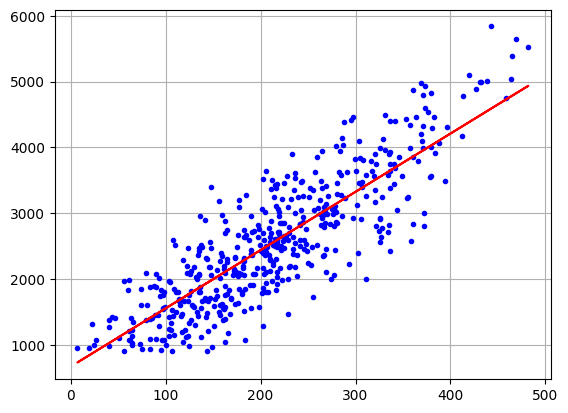

In [207]:
# validate
yp = lr.predict(X_val)  # predictions with validation set
RMSE = np.sqrt(mean_squared_error(y_pred=yp, y_true=y_val))  # RMSE = sqrt(MSE)
print("RMSE = {:.2f}".format(RMSE))

# plot
plt.plot(X_val, y_val, "b.", X_val, yp, "r-");
plt.grid();

coefficients from smallest to highest power:
 [9.44780047e+02 6.00584886e+00 6.11026309e-03]
RMSE = 508.57


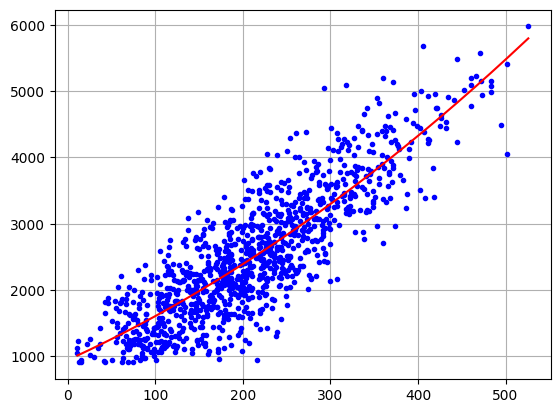

In [208]:
# quadratic regression

# train
degree = 2  # degree of the polynomial
qr = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
qr.fit(X_train, y_train)

# get parameters
c = np.insert(qr.steps[1][1].coef_[0:], 0, qr.steps[1][1].intercept_)
print("coefficients from smallest to highest power:\n", c)

# evaluate
yp = qr.predict(X_train)  # predictions
RMSE = np.sqrt(mean_squared_error(y_pred=yp, y_true=y_train))  # RMSE = sqrt(MSE)
print("RMSE = {:.2f}".format(RMSE))

# plot
i = X_train.argsort(axis=0).flatten()  # sort data points to get a smooth curve!
plt.plot(X_train, y_train, "b.", X_train[i], yp[i], "r-");
plt.grid();

RMSE = 502.56


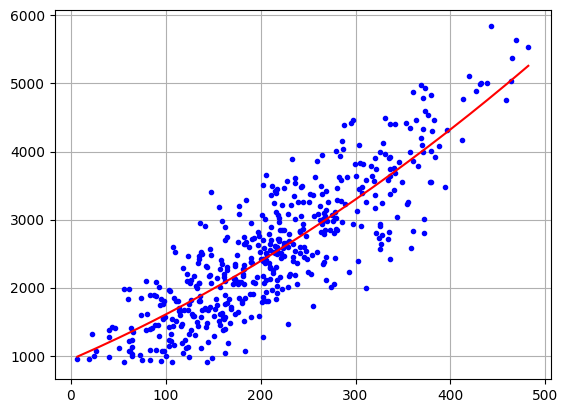

In [209]:
# validate
yp = qr.predict(X_val)  # predictions with validation set
RMSE = np.sqrt(mean_squared_error(y_pred=yp, y_true=y_val))  # RMSE = sqrt(MSE)
print("RMSE = {:.2f}".format(RMSE))

# plot
i = X_val.argsort(axis=0).flatten()
plt.plot(X_val, y_val, "b.", X_val[i], yp[i], "r-");
plt.grid();

There is only a slight improvement in RMSE, which is not significant. Additionally, the coefficient of the squared term is very small, so we approximately get the equation of a straight line again. Be aware of the vertical exaggeration of the axes when checking the plot...

Therefore, we choose the simplest model, namely linear regression, and perform a final test.

RMSE = 510.42


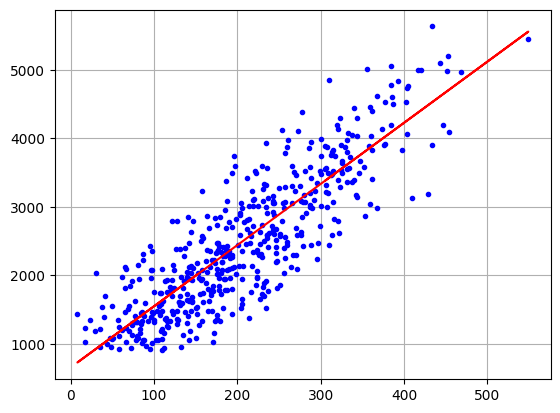

In [210]:
# train again with training + validation set
lr.fit(X_train_val, y_train_val)

# evaluate using test set
yp = lr.predict(X_test)  # predictions with test set
RMSE = np.sqrt(mean_squared_error(y_pred=yp, y_true=y_test))  # RMSE = sqrt(MSE)
print("RMSE = {:.2f}".format(RMSE))

# plot
plt.plot(X_test, y_test, "b.", X_test, yp, "r-");
plt.grid();

The RMSE for the test set is acceptable. So the final model is the linear regression model, which is retrained on full dataset.

Slope = 8.91
Intercept = 651.64
RMSE = 511.33


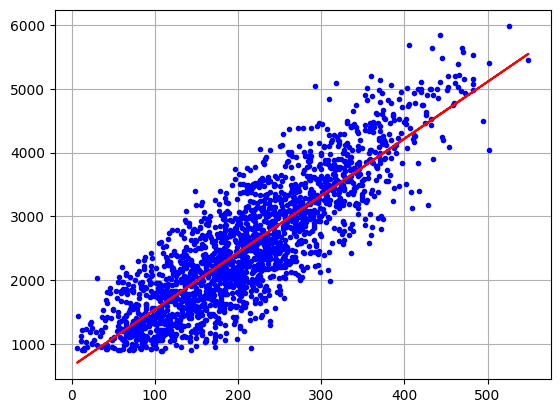

In [211]:
# final training of linear regression model using the full dataset
lr.fit(X, y)
print("Slope = {:.2f}".format(lr.coef_[0]))
print("Intercept = {:.2f}".format(lr.intercept_))

# final evaluation
yp = lr.predict(X)  # predictions
RMSE = np.sqrt(mean_squared_error(y_pred=yp, y_true=y))  # RMSE = sqrt(MSE)
print("RMSE = {:.2f}".format(RMSE))

# plot
plt.plot(X, y, "b.", X, yp, "r-");
plt.grid();

The RMSE of this final model is still acceptable.

### Exercise 15

Read the file "linkedIn.csv" again into a Pandas DataFrame. Do the same as in the previous exercise 14, but this time applying **K-fold cross-validation** instead of simple hold-out validation. Use 15 folds. Don't forget to first take 500 random data points for the test set.


#### Solution

In [228]:
# import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, make_scorer

In [229]:
# read the dataset
df = pd.read_csv("linkedIn.csv")
ylabel, xlabel = "salary", "connections"
df.rename(columns={"loon": ylabel, "connecties": xlabel}, inplace=True)
df.head()

,salary,connections
0,3252,304
1,2968,216
2,2976,159
3,3255,273
4,1953,191


Dataset Splitting

In [230]:
# feature and target
X = df[[xlabel]]
y = df[ylabel]

# here only training- and testset needed because we apply K-fold cross-validation
n_test = 500
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=n_test, random_state=25)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1564, 1) (1564,)
(500, 1) (500,)


K-fold cross-validation with K = 15

In [231]:
# linear regression
lr = LinearRegression()  # instantiate
scores = cross_validate(lr, X_train, y_train,
                        scoring=make_scorer(mean_squared_error),  # MSE
                        cv=15,  # cv is the number of folds
                        return_train_score=True)  # we also want to know the training score

RMSE_train = np.sqrt(scores["train_score"]).mean()
RMSE_val = np.sqrt(scores["test_score"]).mean()

print(f"average RMSE training is {RMSE_train: .2f}")
print(f"average RMSE validation is {RMSE_val: .2f}")

average RMSE training is  512.60
average RMSE validation is  512.37


In [232]:
# quadratic regression
qr = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
scores = cross_validate(qr, X_train, y_train,
                        scoring=make_scorer(mean_squared_error),  # MSE
                        cv=15,  # cv is the number of folds
                        return_train_score=True)  # we also want to know the training score

RMSE_train = np.sqrt(scores["train_score"]).mean()
RMSE_val = np.sqrt(scores["test_score"]).mean()

print(f"average RMSE training is {RMSE_train: .2f}")
print(f"average RMSE validation is {RMSE_val: .2f}")

average RMSE training is  507.50
average RMSE validation is  507.35


We notice only a small improvement in RMSE, so we choose the simplest model, namely linear regression, and do a final test.

In [233]:
# test
lr.fit(X_train, y_train) # fit again using all folds
yp = lr.predict(X_test)  # predictions with test set
RMSE = np.sqrt(mean_squared_error(y_pred=yp, y_true=y_test))
print("RMSE = {:.2f}".format(RMSE))

RMSE = 507.58


The RMSE for the test set is still acceptable, so the final model is the linear regression model, which is retrained on the full dataset.

Slope = 8.91
Intercept = 651.64
RMSE = 511.33


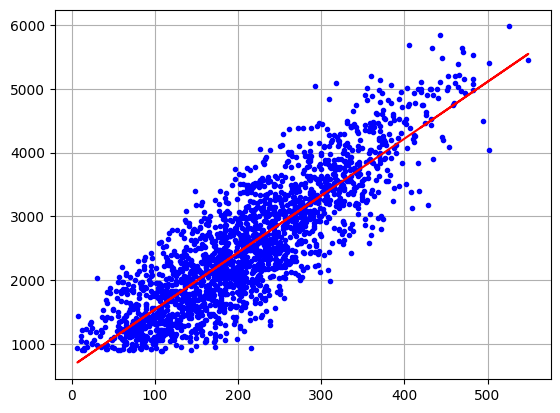

In [234]:
# final training of linear regression model using the full dataset
lr.fit(X, y)
print("Slope = {:.2f}".format(lr.coef_[0]))
print("Intercept = {:.2f}".format(lr.intercept_))

# final evaluation
yp = lr.predict(X)  # predictions
RMSE = np.sqrt(mean_squared_error(y_pred=yp, y_true=y))  # RMSE = sqrt(MSE)
print("RMSE = {:.2f}".format(RMSE))

# plot
plt.plot(X, y, "b.", X, yp, "r-");
plt.grid();

---